In [1]:
from load_helm_table import load_helm_table
import numpy as np
import matplotlib.pyplot as plt

In [2]:
table = load_helm_table("helmholtz/helm_table.dat")
log_rho = table["log_rho"] # shape 541
log_T   = table["log_T"]   # shape 201

  Block 1 shape: (108741, 9)
  Loaded 9 arrays of shape (541, 201).
  log_rho: [-12.0, 15.0]  (541 points, 0.0500 dex/step)
  log_T  : [3.0, 13.0]  (201 points, 0.0500 dex/step)


In [3]:
rho_2d, T_2d = np.meshgrid(10**log_rho, 10**log_T, indexing="ij") # rho = rho_2d; T = T_2d

fd = table["fd"]
fdd = table["fdd"]
fdt = table["fdt"]
ftt = table["ftt"]

P = rho_2d**2 * fd
dPdT_rho = rho_2d**2 * fdt
dPdrho_T = rho_2d**2 * fdd + 2*rho_2d * fd
c_v = -T_2d * ftt

In [4]:
# Construct Gamma
x_rho = (rho_2d/P) * dPdrho_T
x_T = (T_2d/P) * dPdT_rho
Gamma = x_rho + (P * x_T**2) / (rho_2d*T_2d*c_v)

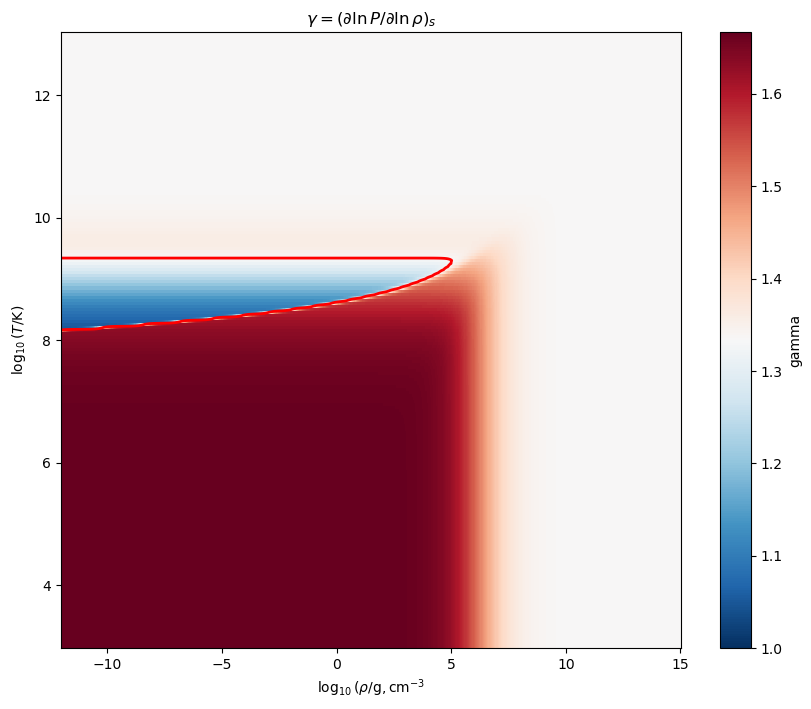

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(log_rho, log_T, Gamma.T, 
                   shading="auto", cmap="RdBu_r", vmin=1.0, vmax=5/3) # same cmap as the plot

ax.contour(log_rho, log_T, Gamma.T, levels=[4/3], colors="r", linewidths = 2)
plt.colorbar(im, ax=ax, label="gamma")
ax.set_xlabel(r"$\log_{10}(\rho / \mathrm{g,cm^{-3}}$")
ax.set_ylabel(r"$\log_{10}(T/\mathrm{K})$")
ax.set_title(r"$\gamma = (\partial\ln{P}/\partial\ln{\rho})_s$")

plt.show()

In [6]:
# Implment Helmholtz Interpolation Hermite Function
from load_helm_table import (
    IMAX, JMAX,
    log_d_min, log_d_max,
    log_t_min, log_t_max,
)

In [7]:
# Defining Quintic Hermite basis function and their first and second derivatives

# We need thhe first and second derivative of QH basis function because because the EOS
# is built by interpolating the Helmholtz free energy and then differentiating it.
# First derivatives give thermodynamic quantities such as pressure and entropy
#, while second derivatives give their response functions
#, such as dP/d\rho, dP/dT, heat capacity, and the quantities needed for gamma

# Each grid point is defined on z in [0,1].

# Quitic Hermite basis function:
def psi0(z): 
    return -6*z**5 + 15*z**4 - 10*z**3 + 1
def psi1(z): 
    return -3*z**5 + 8*z**4 - 6*z**3 + z
def psi2(z): 
    return 0.5 * (
    -z**5 + 3*z**4 - 3*z**3 + z**2
    )

# First derivative of Quintic hermite basis function:
def dpsi0(z):
    return -30*z**4 + 60*z**3 - 30*z**2
def dpsi1(z):
    return -15*z**4 + 32*z**3 - 18*z**2 + 1
def dpsi2(z):
    return 0.5*(
    -5*z**4 + 12*z**3 - 9*z**2 + 2*z
    )

# Second derivative of Quintic hermite basis function:
def ddpsi0(z):
    return -120*z**3 + 180*z**2 - 60*z
def ddpsi1(z):
    return -60*z**3 + 96*z**2 - 36*z
def ddpsi2(z):
    return 0.5*(
    -20*z**3 + 36*z**2 - 18*z + 2
    )

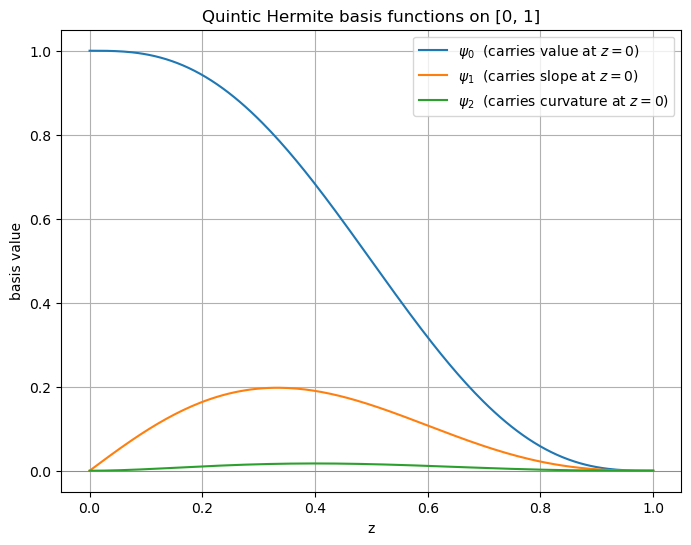

In [8]:
z = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(z, psi0(z), label=r'$\psi_0$  (carries value at $z=0$)')
ax.plot(z, psi1(z), label=r'$\psi_1$  (carries slope at $z=0$)')
ax.plot(z, psi2(z), label=r'$\psi_2$  (carries curvature at $z=0$)')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('z')
ax.set_ylabel('basis value')
ax.legend()
plt.grid()
ax.set_title('Quintic Hermite basis functions on [0, 1]')
plt.show()

In [9]:
# Since the grid of Helmholtz free energy grid is in log space: 
# log rho in 540 equal steps
# log T in 200 steps

LOG_RHO = (log_d_max - log_d_min) / (IMAX - 1)
LOG_T = (log_t_max - log_t_min) / (JMAX - 1)

def find_cell(rho, T):
    """
    Return (i, j) so grid_rho[i] <= rho < gird_rho[i+1]
    """
    log_rho = np.log10(rho)
    log_T = np.log10(T)
    i = int((log_rho - log_d_min) / LOG_RHO)
    j = int((log_T - log_t_min) / LOG_T)
    i = max(0, min(i, IMAX - 2))
    j = max(0, min(j, JMAX - 2))
    
    return i, j

In [10]:
# Basis Weights for one direction, switchable between value/1st/2nd derivative
# Need to convert the local cell cooridnate to the real physical variables rho and T
# psi0(z) carries the value at the left grid point
# psi1(z) carries the slope at the left grid point, which is d/dlog_rho or d/dlog_T
# psi2(z) carries the curvature at the left grid point
# , which is d^2/dlog_rho^2 or d^2/dlog_T^2

# psi0(1-z) carries the value at the right grid point
# psi1(1-z) carries the slope at the right grid point, which is d/dlog_rho or d/dlog_T
# psi2(1-z) carries the curvature at the right grid point
# , which is d^2/dlog_rho^2 or d^2/dlog_T^2

def basis_weights(z, h, derivative_order):
    """
    Compute (w0_L, w1_L, w2_L) for the left grid point 
    and (w0_R, w1_R, w2_R) for the right grid point
    """
    if derivative_order == 0:
        return (
            psi0(z), psi1(z) * h, psi2(z) * h**2,
            psi0(1-z), -psi1(1-z) * h, psi2(1-z) * h**2,
        )
    elif derivative_order == 1:
        return (
            dpsi0(z) / h, dpsi1(z), dpsi2(z) * h,
            -dpsi0(1-z) / h, dpsi1(1-z), -dpsi2(1-z) * h,
        )
    elif derivative_order == 2:
        return (
            ddpsi0(z) / h**2, ddpsi1(z) / h, ddpsi2(z),
            ddpsi0(1-z) / h**2, -ddpsi1(1-z) / h, ddpsi2(1-z),
        )
    else: 
        raise ValueError(f"derivative_order must be 0, 1, or 2")

In [11]:
# implementing Biquintic Hermite Interpolation, with the swicthable derivative orders
def biquintic_hermite_interpolation(table, rho, T, order_rho=0, order_T=0):
    """
    F            -> (0, 0)
    dFd(rho)     -> (1, 0)
    dFdT         -> (0, 1)
    d2Fd(rho)2   -> (2, 0)
    d2FdT2       -> (0, 2)
    d2Fd(rho)dT  -> (1, 1)
    d3Fd2(rho)dT -> (2, 1)
    d3Fd(rho)d2T -> (1, 2)
    d4Fd2(rho)d2T-> (2, 2)
    """
    i, j = find_cell(rho, T)

    # Define x and y, Eq.18 in Timme's paper
    rho_lo  = 10**table["log_rho"][i]
    rho_hi  = 10**table["log_rho"][i+1]
    T_lo    = 10**table["log_T"][j]
    T_hi    = 10**table["log_T"][j+1]

    # Define the scale h
    h_rho = rho_hi - rho_lo
    h_T   = T_hi - T_lo

    x = (rho - rho_lo) / h_rho
    y = (T - T_lo) / h_T

    # Extract the weighted basis (w:= wighted; n = 0, 1, 2; d: rho, t: T;
    # L: left endpoints(z), R: right endpoints(1-z))
    w0dL, w1dL, w2dL, w0dR, w1dR, w2dR = basis_weights(x, h_rho, order_rho)
    w0tL, w1tL, w2tL, w0tR, w1tR, w2tR = basis_weights(y, h_T, order_T) 

    # Extracting value from Helmholtz free enrgy table
    f, fd, ft         = table["f"], table["fd"], table["ft"]
    fdd, ftt, fdt     = table["fdd"], table["ftt"], table["fdt"]
    fddt, fdtt, fddtt = table["fddt"], table["fdtt"], table["fddtt"]

    # With those extracted value, construct the 2D Biquintic Hermite interpolation polynomial
    return (
        # F -> (0, 0)
        f[i, j]      * w0dL * w0tL + f[i+1, j]      * w0dR * w0tL + 
        f[i, j+1]    * w0dL * w0tR + f[i+1, j+1]    * w0dR * w0tR +
        # dFd(rho) -> (1, 0)
        fd[i, j]     * w1dL * w0tL + fd[i+1, j]     * w1dR * w0tL + 
        fd[i, j+1]   * w1dL * w0tR + fd[i+1, j+1]   * w1dR * w0tR +
        # d2Fd(rho)2 -> (2, 0)
        fdd[i, j]    * w2dL * w0tL + fdd[i+1, j]    * w2dR * w0tL +
        fdd[i, j+1]  * w2dL * w0tR + fdd[i+1, j+1]  * w2dR * w0tR +
        # dFdT -> (0, 1)
        ft[i, j]     * w0dL * w1tL + ft[i+1, j]     * w0dR * w1tL + 
        ft[i, j+1]   * w0dL * w1tR + ft[i+1, j+1]   * w0dR * w1tR +
        # d2FdT2 -> (0, 2)
        ftt[i, j]    * w0dL * w2tL + ftt[i+1, j]    * w0dR * w2tL +
        ftt[i, j+1]  * w0dL * w2tR + ftt[i+1, j+1]  * w0dR * w2tR +
        # d2Fd(rho)dT -> (1, 1)
        fdt[i, j]    * w1dL * w1tL + fdt[i+1, j]    * w1dR * w1tL + 
        fdt[i, j+1]  * w1dL * w1tR + fdt[i+1, j+1]  * w1dR * w1tR +
        # d3Fd2(rho)dT -> (2, 1)
        fddt[i, j]   * w2dL * w1tL + fddt[i+1, j]   * w2dR * w1tL + 
        fddt[i, j+1] * w2dL * w1tR + fddt[i+1, j+1] * w2dR * w1tR +
        # d3Fd(rho)d2T -> (1, 2)
        fdtt[i, j]   * w1dL * w2tL + fdtt[i+1, j]   * w1dR * w2tL + 
        fdtt[i, j+1] * w1dL * w2tR + fdtt[i+1, j+1] * w1dR * w2tR +
        # d4Fd2(rho)d2T -> (2, 2)
        fddtt[i, j]  * w2dL * w2tL + fddtt[i+1, j]  * w2dR * w2tL + 
        fddtt[i, j+1]* w2dL * w2tR + fddtt[i+1, j+1]* w2dR * w2tR
    )


In [12]:
def biquintic_F(table, rho, T):           return biquintic_hermite_interpolation(table, rho, T, 0, 0)
def biquintic_F_rho(table, rho, T):       return biquintic_hermite_interpolation(table, rho, T, 1, 0)
def biquintic_F_T(table, rho, T):         return biquintic_hermite_interpolation(table, rho, T, 0, 1)
def biquintic_F_rho_rho(table, rho, T):   return biquintic_hermite_interpolation(table, rho, T, 2, 0)
def biquintic_F_TT(table, rho, T):        return biquintic_hermite_interpolation(table, rho, T, 0, 2)
def biquintic_F_rho_T(table, rho, T):     return biquintic_hermite_interpolation(table, rho, T, 1, 1)

In [13]:
# Helper function that firectly returen the F and all five unique partials in one dict.
def helm_F_and_derivs(table, rho, T):
    # F and its 5 unique partial derivatives at one (rho, T) point.
    return {
        'F':          biquintic_hermite_interpolation(table, rho, T, 0, 0),
        'dF/drho':    biquintic_hermite_interpolation(table, rho, T, 1, 0),
        'dF/dT':      biquintic_hermite_interpolation(table, rho, T, 0, 1),
        'd2F/drho2':  biquintic_hermite_interpolation(table, rho, T, 2, 0),
        'd2F/dT2':    biquintic_hermite_interpolation(table, rho, T, 0, 2),
        'd2F/drhodT': biquintic_hermite_interpolation(table, rho, T, 1, 1),
    }

In [14]:
table = load_helm_table('helmholtz/helm_table.dat')   # adjust path if needed

rng = np.random.default_rng(seed=42)
test_i = rng.integers(low=10, high=IMAX - 10, size=5)
test_j = rng.integers(low=10, high=JMAX - 10, size=5)

print(f"{'i':>4s} {'j':>4s} | {'F_table':>14s} {'F_interp':>14s} {'rel.err':>10s}")
print('-' * 60)
for i, j in zip(test_i, test_j):
    rho = 10.0 ** table['log_rho'][i]
    T   = 10.0 ** table['log_T'][j]
    F_table  = table['f'][i, j]
    F_interp = helm_F_and_derivs(table, rho, T)['F']
    rel_err  = abs(F_interp - F_table) / abs(F_table)
    print(f'{i:>4d} {j:>4d} | {F_table:>+14.4e} {F_interp:>+14.4e} {rel_err:>10.1e}')

  Block 1 shape: (108741, 9)
  Loaded 9 arrays of shape (541, 201).
  log_rho: [-12.0, 15.0]  (541 points, 0.0500 dex/step)
  log_T  : [3.0, 13.0]  (201 points, 0.0500 dex/step)
   i    j |        F_table       F_interp    rel.err
------------------------------------------------------------
  56  165 |    -6.9930e+39    -6.9930e+39    0.0e+00
 413   25 |    +2.4056e+18    +2.4056e+18    0.0e+00
 351  136 |    -1.7133e+19    -1.7133e+19    0.0e+00
 238   46 |    -1.1613e+13    -1.1613e+13    0.0e+00
 235   27 |    +9.7589e+12    +9.7589e+12    0.0e+00


In [15]:
# Self-tests function written by Claude

def _test_basis_endpoints():
    """Verify basis-function and derivative endpoint conditions."""
    print("Test 1: Basis function endpoint values and derivatives")
    cases = [
        ("psi_0(0)", psi0(0.0), 1.0),
        ("psi_0(1)", psi0(1.0), 0.0),
        ("psi_1(0)", psi1(0.0), 0.0),
        ("psi_1(1)", psi1(1.0), 0.0),
        ("psi_2(0)", psi2(0.0), 0.0),
        ("psi_2(1)", psi2(1.0), 0.0),
        ("dpsi_0(0)", dpsi0(0.0), 0.0),
        ("dpsi_1(0)", dpsi1(0.0), 1.0),
        ("dpsi_2(0)", dpsi2(0.0), 0.0),
        ("ddpsi_0(0)", ddpsi0(0.0), 0.0),
        ("ddpsi_1(0)", ddpsi1(0.0), 0.0),
        ("ddpsi_2(0)", ddpsi2(0.0), 1.0),
    ]
    all_ok = True
    for name, got, expected in cases:
        ok = abs(got - expected) < 1e-12
        all_ok &= ok
        status = "OK" if ok else "FAIL"
        print(f"  {name:>11s} = {got:+.3e}   (expected {expected:.0e})   [{status}]")
    return all_ok

In [16]:
def _test_grid_point_consistency(table, n_test=6, seed=42):
    """At a grid point, interpolated values should match tabulated values
    exactly (down to floating-point precision) for F AND all 5 derivatives.
 
    This is the killer test: it exercises the basis weights at all six
    derivative orders, the 36-term sum, and the right-endpoint signs."""
    print("\nTest 2: Interpolation at grid points (all 6 quantities)")
    print("(should reproduce table to floating-point precision)")
 
    rng = np.random.default_rng(seed)
    test_i = rng.integers(low=10, high=IMAX - 10, size=n_test)
    test_j = rng.integers(low=10, high=JMAX - 10, size=n_test)
 
    quantities = [
        ("F",            "f",     (0, 0)),
        ("dF/drho",      "fd",    (1, 0)),
        ("dF/dT",        "ft",    (0, 1)),
        ("d2F/drho2",    "fdd",   (2, 0)),
        ("d2F/dT2",      "ftt",   (0, 2)),
        ("d2F/drhodT",   "fdt",   (1, 1)),
    ]
 
    max_err_per_q = {name: 0.0 for name, _, _ in quantities}
 
    for i, j in zip(test_i, test_j):
        rho = 10.0 ** table["log_rho"][i]
        T = 10.0 ** table["log_T"][j]
        for name, key, (m_rho, m_T) in quantities:
            tab_val = table[key][i, j]
            int_val = biquintic_hermite_interpolation(table, rho, T, m_rho, m_T)
            if abs(tab_val) > 1e-300:
                rel_err = abs(int_val - tab_val) / abs(tab_val)
            else:
                rel_err = abs(int_val - tab_val)
            max_err_per_q[name] = max(max_err_per_q[name], rel_err)
 
    print(f"\n  Max relative error across {n_test} random grid points:")
    all_ok = True
    for name in max_err_per_q:
        err = max_err_per_q[name]
        ok = err < 1e-10
        all_ok &= ok
        status = "OK" if ok else "FAIL"
        print(f"    {name:>11s}:  max rel.err = {err:.2e}   [{status}]")
 
    return all_ok

In [17]:
def _test_off_grid_values(table):
    """Spot-check that off-grid evaluations give finite values."""
    print("\nTest 3: Off-grid spot-checks (should all be finite)")
    points = [
        (1e0, 1e6),     # cool, low-density
        (1e3, 1e9),     # warm
        (1e6, 1e10),    # high-T, denser (pair-production regime)
        (1e9, 3e8),     # degenerate electrons
    ]
    for rho, T in points:
        d = helm_F_and_derivs(table, rho, T)
        ok = all(np.isfinite(v) for v in d.values())
        print(f"  (rho={rho:.0e}, T={T:.0e}):  "
              + ", ".join(f"{k}={v:+.2e}" for k, v in d.items())
              + f"   [{'OK' if ok else 'FAIL'}]")

In [18]:
if __name__ == "__main__":
 
    print("=" * 70)
    print("Phase 3b: Biquintic Hermite interpolation of F and derivatives")
    print("=" * 70)
 
    pass_1 = _test_basis_endpoints()
    print()
    table = load_helm_table("helm_table.dat")
    pass_2 = _test_grid_point_consistency(table)
    _test_off_grid_values(table)
 
    print("\n" + "=" * 70)
    if pass_1 and pass_2:
        print("All required tests PASSED.  Ready for plotting Gamma map.")
    else:
        print("One or more tests FAILED.  Fix before moving on.")
    print("=" * 70)

Phase 3b: Biquintic Hermite interpolation of F and derivatives
Test 1: Basis function endpoint values and derivatives
     psi_0(0) = +1.000e+00   (expected 1e+00)   [OK]
     psi_0(1) = +0.000e+00   (expected 0e+00)   [OK]
     psi_1(0) = +0.000e+00   (expected 0e+00)   [OK]
     psi_1(1) = +0.000e+00   (expected 0e+00)   [OK]
     psi_2(0) = +0.000e+00   (expected 0e+00)   [OK]
     psi_2(1) = +0.000e+00   (expected 0e+00)   [OK]
    dpsi_0(0) = +0.000e+00   (expected 0e+00)   [OK]
    dpsi_1(0) = +1.000e+00   (expected 1e+00)   [OK]
    dpsi_2(0) = +0.000e+00   (expected 0e+00)   [OK]
   ddpsi_0(0) = +0.000e+00   (expected 0e+00)   [OK]
   ddpsi_1(0) = +0.000e+00   (expected 0e+00)   [OK]
   ddpsi_2(0) = +1.000e+00   (expected 1e+00)   [OK]

  Block 1 shape: (108741, 9)
  Loaded 9 arrays of shape (541, 201).
  log_rho: [-12.0, 15.0]  (541 points, 0.0500 dex/step)
  log_T  : [3.0, 13.0]  (201 points, 0.0500 dex/step)

Test 2: Interpolation at grid points (all 6 quantities)
(should re

In [80]:
# Now, I am trying to figure out the total pressure, then get the gamma from total pressure
# Composition: Pure Helium. (The task later Im trying to examine the total pressure for Bare Helium Core)
from scipy.constants import c, k, hbar, R

h_bar = hbar * 10**7 # erg s
k_B = k * 10**7      # erg/K
R_gas = R * 10**7    # erg/(mol*K)
c_cgs = c * 10**2      # m/s → cm/s


pi = np.pi
Y_e = 0.5
mu_i = 4

# The physical density at each grid point is rho_phys = rho_table / Y_e
rho_table_2d = rho_2d
rho_phys_2d = rho_table_2d / Y_e 

In [81]:
# Since we are considering the case of He now, the electron pressure needs to be scaled with new Y_e
P_e = rho_table_2d**2 * fd
dPdT_e = rho_table_2d**2 * fdt
dPdrho_e = Y_e * (rho_table_2d**2 * fdd + 2*rho_table_2d * fd)
c_v_e = -Y_e * T_2d * ftt

# Radiation Pressure
a_rad = (pi**2 * k_B**4) / (15*h_bar**3 * c_cgs**3)

P_rad = (1/3) * a_rad * T_2d**4
dPdT_rad = (4/3) * a_rad * T_2d**3
dPdrho_rad = 0
c_v_rad = (4 * a_rad * T_2d**3) / rho_phys_2d

# Ideal gas pressure
P_ion = rho_phys_2d * R_gas * T_2d / mu_i
dPdT_ion = rho_phys_2d * R_gas / mu_i
dPdrho_ion = R_gas * T_2d / mu_i
c_v_ion = (3/2) * R_gas / mu_i

# Total Pressure and 
P_tot = P_e + P_rad + P_ion
dPdT_tot = dPdT_e + dPdT_ion + dPdT_rad
dPdrho_tot = dPdrho_e + dPdrho_ion + dPdrho_rad
c_v_tot = c_v_e + c_v_ion + c_v_rad

# Gamma from totals
chi_rho = rho_phys_2d * dPdrho_tot / P_tot
chi_T   = T_2d        * dPdT_tot   / P_tot
Gamma_total = chi_rho + P_tot * chi_T**2 / (rho_phys_2d * T_2d * c_v_tot)

a_rad

7.565733250280001e-15

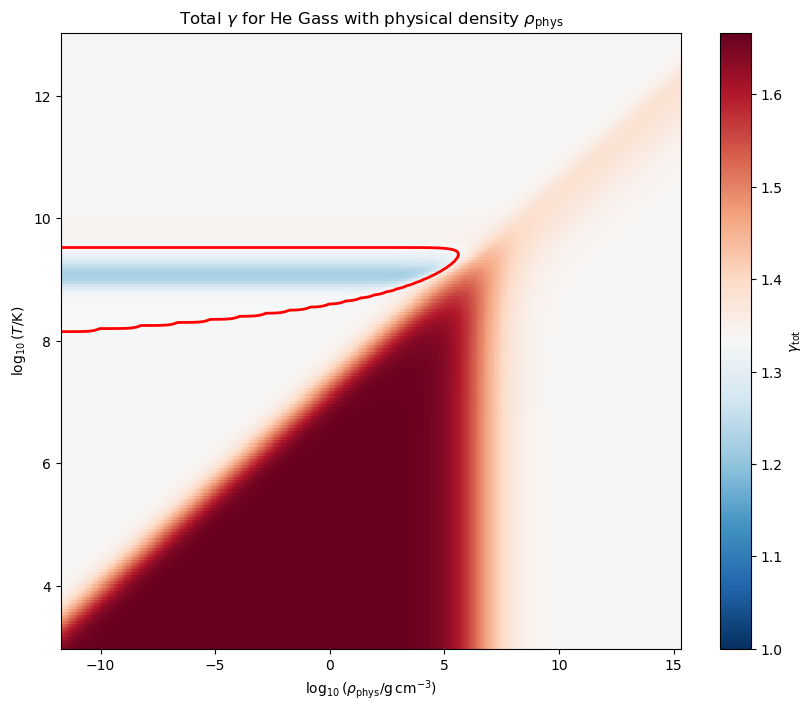

In [82]:
log_rho_phys = log_rho + np.log10(1 / Y_e)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(log_rho_phys, log_T, Gamma_total.T,
                   shading="auto", cmap="RdBu_r", vmin=1.0, vmax=5/3)

ax.contour(log_rho_phys, log_T, Gamma_total.T, levels=[4/3],
           colors="r", linewidths=2)
plt.colorbar(im, ax=ax, label=r"$\gamma_{\rm tot}$")
ax.set_xlabel(r"$\log_{10}(\rho_{\rm phys} / \mathrm{g\,cm^{-3}})$")
ax.set_ylabel(r"$\log_{10}(T / \mathrm{K})$")
ax.set_title(r"Total $\gamma$ for He Gass with physical density $\rho_{\rm phys}$")

plt.show()

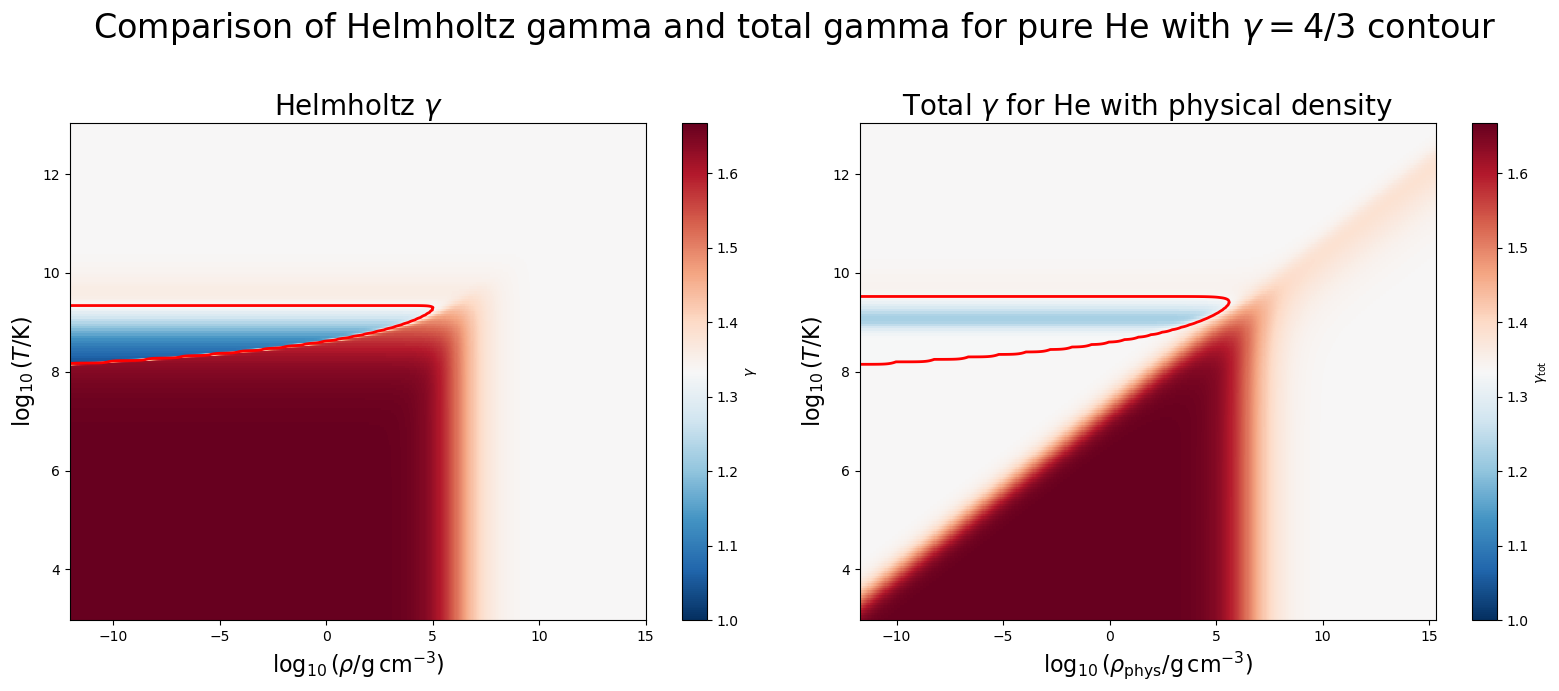

In [93]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left plot: Gamma from Helmholtz free energy only
im1 = ax1.pcolormesh(log_rho, log_T, Gamma.T, 
                     shading="auto", cmap="RdBu_r", vmin=1.0, vmax=5/3)
ax1.contour(log_rho, log_T, Gamma.T, levels=[4/3], colors="r", linewidths=2)
plt.colorbar(im1, ax=ax1, label=r"$\gamma$")
ax1.set_xlabel(r"$\log_{10}(\rho / \mathrm{g\,cm^{-3}})$", fontsize="16")
ax1.set_ylabel(r"$\log_{10}(T/\mathrm{K})$", fontsize="16")
ax1.set_title(r"Helmholtz $\gamma$", fontsize="20")

# Right plot: Total gamma with radiation and ion pressure
im2 = ax2.pcolormesh(log_rho_phys, log_T, Gamma_total.T,
                     shading="auto", cmap="RdBu_r", vmin=1.0, vmax=5/3)
ax2.contour(log_rho_phys, log_T, Gamma_total.T, levels=[4/3],
            colors="r", linewidths=2)
plt.colorbar(im2, ax=ax2, label=r"$\gamma_{\rm tot}$")
ax2.set_xlabel(r"$\log_{10}(\rho_{\rm phys} / \mathrm{g\,cm^{-3}})$", fontsize="16")
ax2.set_ylabel(r"$\log_{10}(T / \mathrm{K})$", fontsize="16")
ax2.set_title(r"Total $\gamma$ for He with physical density", fontsize="20")

plt.suptitle("Comparison of Helmholtz gamma and total gamma for pure He with $\gamma = 4/3$ contour", fontsize="24")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

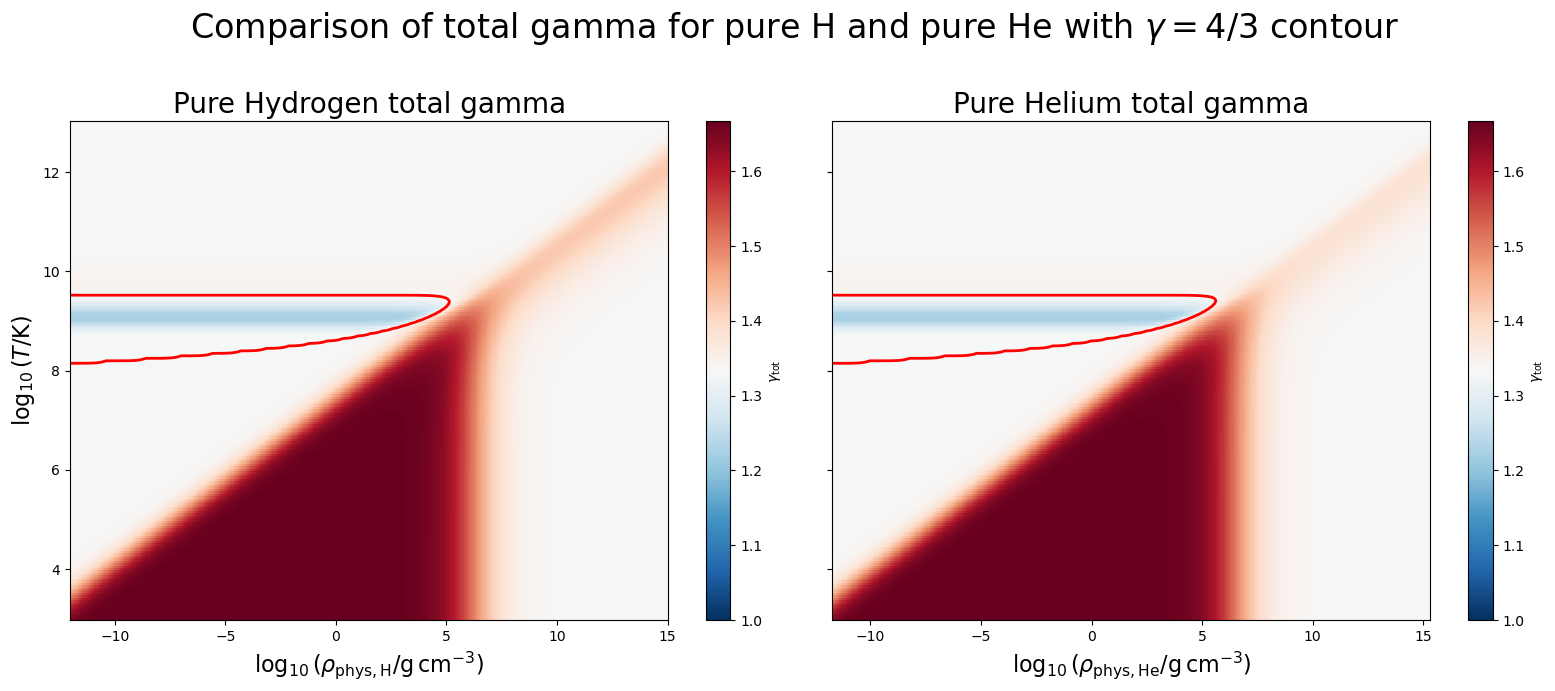

In [91]:
def compute_total_pressure_and_gamma(Y_e, mu_i):
    rho_phys = rho_table_2d / Y_e

    P_e = rho_table_2d**2 * fd
    dPdT_e = rho_table_2d**2 * fdt
    dPdrho_e = Y_e * (rho_table_2d**2 * fdd + 2 * rho_table_2d * fd)
    c_v_e = -Y_e * T_2d * ftt

    P_rad = (1/3) * a_rad * T_2d**4
    dPdT_rad = (4/3) * a_rad * T_2d**3
    c_v_rad = (4 * a_rad * T_2d**3) / rho_phys

    P_ion = rho_phys * R_gas * T_2d / mu_i
    dPdT_ion = rho_phys * R_gas / mu_i
    dPdrho_ion = R_gas * T_2d / mu_i
    c_v_ion = 1.5 * R_gas / mu_i

    P_tot = P_e + P_rad + P_ion
    dPdT_tot = dPdT_e + dPdT_ion + dPdT_rad
    dPdrho_tot = dPdrho_e + dPdrho_ion
    c_v_tot = c_v_e + c_v_ion + c_v_rad

    chi_rho = rho_phys * dPdrho_tot / P_tot
    chi_T = T_2d * dPdT_tot / P_tot
    Gamma_tot = chi_rho + P_tot * chi_T**2 / (rho_phys * T_2d * c_v_tot)

    return P_tot, Gamma_tot

Y_e_H, mu_i_H = 1.0, 1.0
Y_e_He, mu_i_He = 0.5, 4.0

P_tot_H, Gamma_tot_H = compute_total_pressure_and_gamma(Y_e_H, mu_i_H)
P_tot_He, Gamma_tot_He = compute_total_pressure_and_gamma(Y_e_He, mu_i_He)

log_rho_phys_H = log_rho
log_rho_phys_He = log_rho + np.log10(1.0 / Y_e_He)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

im1 = ax1.pcolormesh(
    log_rho_phys_H, log_T, Gamma_tot_H.T,
    shading="auto", cmap="RdBu_r", vmin=1.0, vmax=5/3
)
ax1.contour(
    log_rho_phys_H, log_T, Gamma_tot_H.T,
    levels=[4/3], colors="r", linewidths=2
)
fig.colorbar(im1, ax=ax1, label=r"$\gamma_{\rm tot}$")
ax1.set_xlabel(r"$\log_{10}(\rho_{\rm phys,H} / \mathrm{g\,cm^{-3}})$", fontsize="16")
ax1.set_ylabel(r"$\log_{10}(T / \mathrm{K})$", fontsize="16")
ax1.set_title("Pure Hydrogen total gamma", fontsize="20")

im2 = ax2.pcolormesh(
    log_rho_phys_He, log_T, Gamma_tot_He.T,
    shading="auto", cmap="RdBu_r", vmin=1.0, vmax=5/3
)
ax2.contour(
    log_rho_phys_He, log_T, Gamma_tot_He.T,
    levels=[4/3], colors="r", linewidths=2
)
fig.colorbar(im2, ax=ax2, label=r"$\gamma_{\rm tot}$")
ax2.set_xlabel(r"$\log_{10}(\rho_{\rm phys,He} / \mathrm{g\,cm^{-3}})$", fontsize="16")
ax2.set_title("Pure Helium total gamma", fontsize="20")

plt.suptitle("Comparison of total gamma for pure H and pure He with $\gamma = 4/3$ contour", fontsize="24")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()